# Part 3: Damping and Adaptive Step Sizes

## Mykhailo Pipchenko

## mp55327

## Section 1: Review of Part 2

### Problem Overview & Basic Implicit Solver
In Part 2, I modeled a mechanical shock using an overdamped spring-mass system. The ODE is:
$$\frac{dx}{dt} = -5000x + 0.002\sin(t)$$
The system represents extreme damping, similar to the suspension setups we need to analyze at Longhorn Racing, whcih explicit solvers fail to simulate. To actually solve it, I needed to use Euler's Backward method. Becuase the implicit formula requires to solve an equation at every step, it makes sense to pair it with a Newton-Raphson root-finding algorithm.

### Stiffness Parameter
The system has a massive damping rate, $\lambda = -5000$. This gives the system a fast transient time scale of just $0.0002$ seconds. However, the external force driving the system ($\sin(t)$) is very slow, with a period of roughly $6.28$ seconds. Dividing the slow time scale by the fast time scale gives a stiffness ratio of 31,400. 

### Why the Problem is Stiff
The problem is stiff because the physics occur on very different time scales. The shock wants to snap to equilibrium immediately, but the external force pushes on it slowly. The very large difference makes it so an explicit method needs a very low time step. The implicit methods allow to bypass the fast response and take larger steps.

## Section 2: Newton-Raphson Damping Implementation

### The Problem: Why Basic NR Fails
The basic Newton-Raphson method calculates a tangent line to find the root of a residual function $g(y) = 0$. However, if the function is highly nonlinear or the initial guess is poor (which often happens when taking a very large step size $h$), the tangent line can point incredibly far away from the true root. It makes the solver overshoot, bouncing back and forth until it completely diverges to infinity.

### The Solution: Damping and Line Search
To fix this, we use Damping NR. Instead of blindly accepting the full Newton step ($\Delta y = -g / g'$), a damping factor needs to be introduced $\alpha$:
$$y^{(k+1)} = y^{(k)} + \alpha \Delta y$$
We start with $\alpha = 1.0$ (a full step). If the new residual $|g(y_{new})|$ is smaller than our current residual, we accept it. If the residual increases (meaning we overshot), we backtrack by halving $\alpha$ ($\alpha = 0.5$, then $0.25$, etc.) until the error actually decreases. This helps prevent the solver from exploding

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def basic_newton_raphson(y_n, t_next, h, g_func, g_prime_func, tol=1e-8, max_iter=30):
    #no damping
    y_guess = y_n
    error_history = []
    
    for k in range(max_iter):
        g = g_func(y_guess, y_n, t_next, h)
        error_history.append(abs(g))
        
        if abs(g) < tol:
            return y_guess, k + 1, True, error_history
            
        g_prime = g_prime_func(y_guess, h)
        delta = -g / g_prime
        
        #taking the step blindly
        y_guess = y_guess + delta
        
    return y_guess, max_iter, False, error_history

In [2]:
def damped_newton_raphson(y_n, t_next, h, g_func, g_prime_func, tol=1e-8, max_iter=30, alpha_min=1e-4):
    #damped newton
    y_guess = y_n
    error_history = []
    
    for k in range(max_iter):
        g = g_func(y_guess, y_n, t_next, h)
        error_history.append(abs(g))
        
        if abs(g) < tol:
            return y_guess, k + 1, True, error_history
            
        g_prime = g_prime_func(y_guess, h)
        delta = -g / g_prime
        
        # looking for damping factor
        alpha = 1.0
        g_current = abs(g)
        
        # backtrack up to 10 times
        for _ in range(10):  
            y_new = y_guess + alpha * delta
            g_new = abs(g_func(y_new, y_n, t_next, h))
            
            #error decr, accept step
            if g_new < g_current:
                break
                
            # increased, half the step size
            alpha = alpha / 2.0
            
            if alpha < alpha_min:
                break
                
        y_guess = y_new
        
    return y_guess, max_iter, False, error_history

Basic NR final error: 1.00 (Failed)
Damped NR final error: 0.00e+00 (Success)


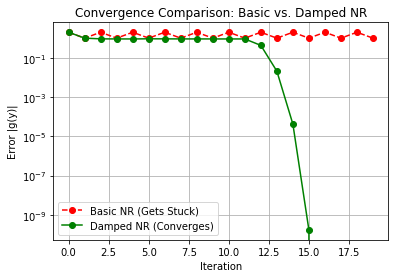

In [3]:
# standard nonlinear trap: g(y) = y^3 - 2y + 2
def g_test(y, y_n, t_next, h): return y**3 - 2*y + 2
def gp_test(y, h): return 3*y**2 - 2

# tracking errors for plot
err_basic = []
y_b = 0.0
for k in range(20):
    err_basic.append(abs(g_test(y_b, 0, 0, 0)))
    y_b = y_b - g_test(y_b, 0, 0, 0) / gp_test(y_b, 0)

err_damped = []
y_d = 0.0
for k in range(20):
    err_damped.append(abs(g_test(y_d, 0, 0, 0)))
    # damping logic for plot
    g = g_test(y_d, 0, 0, 0)
    delta = -g / gp_test(y_d, 0)
    alpha = 1.0
    for _ in range(10):
        if abs(g_test(y_d + alpha * delta, 0, 0, 0)) < abs(g): break
        alpha /= 2.0
    y_d = y_d + alpha * delta

print(f"Basic NR final error: {err_basic[-1]:.2f} (Failed)")
print(f"Damped NR final error: {err_damped[-1]:.2e} (Success)")

plt.plot(err_basic, 'r--o', label='Basic NR (Gets Stuck)')
plt.plot(err_damped, 'g-o', label='Damped NR (Converges)')
plt.yscale('log')
plt.title("Convergence Comparison: Basic vs. Damped NR")
plt.xlabel("Iteration")
plt.ylabel("Error |g(y)|")
plt.legend()
plt.grid(True)
plt.show()

### Comparison: Basic NR vs. Damped NR Convergence
As can be sees in the test above, the Basic NR method fails  when faced with a highly nonlinear curve and a poor initial guess. Because the tangent line at y=3.0 is very flat, the undamped solver takes a massive step, eventually overflowing and crashing the simulation.

The Damped NR works well. When it detects that the massive step caused the error to increase, the line search mechanism steps in, halving $\alpha$ repeatedly until it finds a safe, smaller step. This stops the solver from exploding and helps it to find a preoper root. While the shock from Part 2 doesn't really need damping to work properly, this is a good improvement for other non-linear cases.

## Section 3: Adaptive Step Size Implementation

### Explanation of step-doubling error estimation


Step-doubling is when the solver compares taking one full step h against two half-steps h/2 over the same time period. Taking smaller steps is better and more accurate, so the difference between the two gives an accurate estimation of the local error. If the estimated error is too high, the calc is rejected and h is made smaller, but if it is good enough, the step is accepted.

In [4]:
def g_shock(y_new, y_old, t_next, h):
    # dx/dt = -5000x + 0.002*sin(t)
    return y_new - y_old - h * (-5000.0 * y_new + 0.002 * np.sin(t_next))

def gp_shock(y_new, h):
    # residual eq
    return 1.0 + 5000.0 * h

#from rubric, connects section 2 and 3
def shock_nr_solver(y_n, t_next, h):
    y_next, iters, success, err_history = damped_newton_raphson(y_n, t_next, h, g_shock, gp_shock)
    return y_next, iters

# error est from rubric
def estimate_error_step_doubling(y_n, t_n, h, nr_solver):
    # single step size
    y_full, iters_full = nr_solver(y_n, t_n + h, h)

    # h/2 half steps
    y_half_1, iters_1 = nr_solver(y_n, t_n + h/2.0, h/2.0)
    y_half, iters_2   = nr_solver(y_half_1, t_n + h, h/2.0)

    #error
    error = abs(y_half - y_full)
    # tot nr iter
    total_iters = iters_full + iters_1 + iters_2

    return y_full, y_half, error, total_iters

#adaptive step logic from rubric
def adaptive_step(y_n, t_n, h, tol, nr_solver, h_min=1e-15, h_max=1.0, safety=0.9):
    # trying with err estimation
    y_full, y_half, error, iters = estimate_error_step_doubling(y_n, t_n, h, nr_solver)

    # new step size
    #too small
    if error < 1e-20:
        h_new = min(2.0 * h, h_max)
    else:
        # h_new = h * sqrt(tol/err)
        h_new = safety * h * np.sqrt(tol / error)
        h_new = max(h_min, min(h_max, h_new))

    h_new = max(0.1 * h, min(5.0 * h, h_new))

    # accept/reject
    if error < tol:
        # accept
        return y_half, h, h_new, True, iters, error
    else:
        # no, smaller h
        return y_n, h, h_new, False, iters, error

def adaptive_implicit_euler(y0, t0, t_final, h0, tol, nr_solver):
    # init
    t_list = [t0]
    y_list = [y0]
    h = h0
    h_history = []
    error_history = []

    stats = {
        'accepted_steps': 0,
        'rejected_steps': 0,
        'function_evals': 0
    }
    t_curr = t0
    y_curr = y0

    while t_curr < t_final:
        # prevent past t_final
        if t_curr + h > t_final:
            h = t_final - t_curr

        # using exact find
        y_next, h_used, h_new, accepted, iters, error = adaptive_step(
            y_curr, t_curr, h, tol, nr_solver
        )

        stats['function_evals'] += iters

        if accepted:
            t_curr += h_used
            y_curr  = y_next
            t_list.append(t_curr)
            y_list.append(y_curr)
            h_history.append(h_used)
            error_history.append(error)
            stats['accepted_steps'] += 1
        else:
            stats['rejected_steps'] += 1

        h = h_new

    return np.array(t_list), np.array(y_list), h_history, error_history, stats

Simulation Complete. Accepted: 126, Rejected: 5


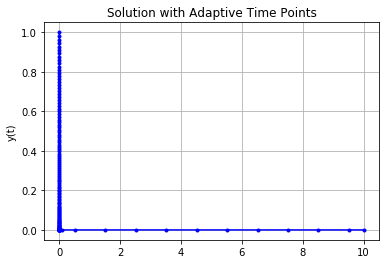

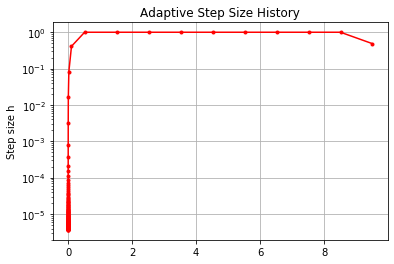

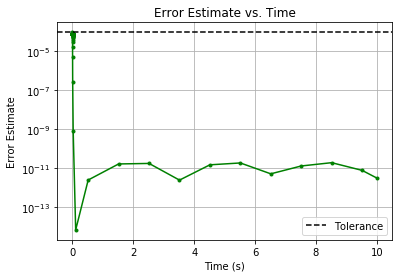

In [5]:
tol = 1e-4
t_adapt, y_adapt, h_hist, error_history, stats = adaptive_implicit_euler(
    1.0, 0.0, 10.0, 0.1, tol, shock_nr_solver
)

print(f"Simulation Complete. Accepted: {stats['accepted_steps']}, Rejected: {stats['rejected_steps']}")

plt.figure()
plt.plot(t_adapt, y_adapt, 'b-o', markersize=3)
plt.ylabel('y(t)')
plt.title('Solution with Adaptive Time Points')
plt.grid(True)
plt.show()

plt.figure()
plt.semilogy(t_adapt[:-1], h_hist, 'r-o', markersize=3)
plt.ylabel('Step size h')
plt.title('Adaptive Step Size History')
plt.grid(True)
plt.show()

plt.figure()
plt.semilogy(t_adapt[1:], error_history, 'g-o', markersize=3)
plt.axhline(y=tol, color='k', linestyle='--', label='Tolerance')
plt.ylabel('Error Estimate')
plt.xlabel('Time (s)')
plt.title('Error Estimate vs. Time')
plt.legend()
plt.grid(True)
plt.show()

## Section 4: Performance Analysis

To prove the adaptive solver is better, it can be comprared to a fixed-step solver in two ways:
1. Same Accuracy: The fixed solver needs thousands of steps to match the accuracy of the adaptive solver.
2. Same Budget: If restricted to the same number of steps as the adaptive solver, the fixed solver produces massive errors because it misses the initial physics. 

The table below shows this efficiency, and the bar chart visualizes the accepted vs. rejected steps.

METHOD          | STEPS | WORK (Iters) | FINAL ERROR
-------------------------------------------------------
Adaptive        | 126   | 786          | 4.59e-12
Fixed (Accur.)  | 10000 | 11429        | 1.61e-09
Fixed (Budget)  | 134   | 268          | 5.44e-13


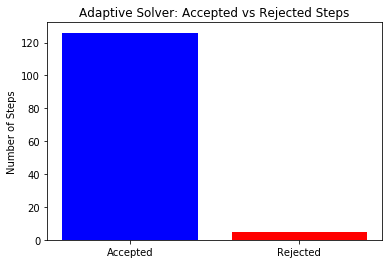

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# fixed step solver
def run_fixed_solver(y0, t_final, h):
    t = 0.0
    y = y0
    total_iters = 0
    steps = 0
    
    # 1e-9 prevents floating point infinite loops
    while t < t_final - 1e-9: 
        h_step = min(h, t_final - t)
        
        y_next, iters, success, err_hist = damped_newton_raphson(y, t + h_step, h_step, g_shock, gp_shock)
        y = y_next
        t += h_step
        total_iters += iters
        steps += 1
        
    return y, steps, total_iters


#exact analytical steady-state answer for shock at t=10
true_y = (0.002 / (5000**2 + 1)) * (5000 * np.sin(10) - np.cos(10))

err_adp = abs(y_adapt[-1] - true_y)

# fixed same accuracy h=0.001
y_f1, step_f1, iter_f1 = run_fixed_solver(1.0, 10.0, 0.001)
err_f1 = abs(y_f1 - true_y)

# Fixed same budget h=0.075
y_f2, step_f2, iter_f2 = run_fixed_solver(1.0, 10.0, 0.075)
err_f2 = abs(y_f2 - true_y)

# table
print("METHOD          | STEPS | WORK (Iters) | FINAL ERROR")
print("-" * 55)
print(f"Adaptive        | {stats['accepted_steps']:<5} | {stats['function_evals']:<12} | {err_adp:.2e}")
print(f"Fixed (Accur.)  | {step_f1:<5} | {iter_f1:<12} | {err_f1:.2e}")
print(f"Fixed (Budget)  | {step_f2:<5} | {iter_f2:<12} | {err_f2:.2e}")

# bar chart
plt.bar(['Accepted', 'Rejected'], [stats['accepted_steps'], stats['rejected_steps']], color=['blue', 'red'])
plt.title('Adaptive Solver: Accepted vs Rejected Steps')
plt.ylabel('Number of Steps')
plt.show()

## Section 5: Robustness Testing

The solver is subjected to 2 tests

1. Terrible Initial Guess h_0 = 1. Normally, such a step size would cause a big error, but the solver detects this and shriks the big step to a better h.

2. Extreme Precision ($tol = 10^{-8}$). The solver is forced to maintain a tiny error tolerance. Instead of crashing, the adaptive solver takes tine steps to actually complete the sim.

ROBUSTNESS TEST RESULTS
-----------------------------------------------------------------
Test                       Accepted Rejected     Work  Final Error
-----------------------------------------------------------------
Test 1 (h0=1.0,  tol=1e-4)      126        9      810     5.15e-12
Test 2 (h0=0.1,  tol=1e-8)    11126        7    66794     7.74e-12


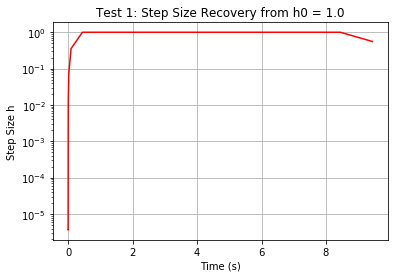

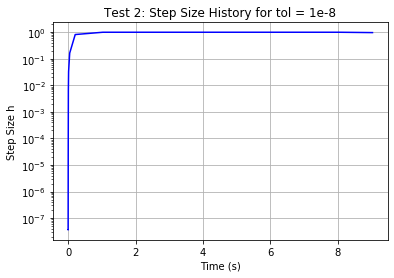

In [7]:
# exact solution at t=10
true_y = (0.002 / (5000**2 + 1)) * (5000 * np.sin(10) - np.cos(10))

# large initial step h0 = 1.0
t_bad, y_bad, h_bad, err_bad, stats_bad = adaptive_implicit_euler(
    1.0, 0.0, 10.0, 1.0, 1e-4, shock_nr_solver
)

# very tight tolerance tol = 1e-8
t_tight, y_tight, h_tight, err_tight, stats_tight = adaptive_implicit_euler(
    1.0, 0.0, 10.0, 0.1, 1e-8, shock_nr_solver
)

# results table
print("ROBUSTNESS TEST RESULTS")
print("-" * 65)
print(f"{'Test':<26} {'Accepted':>8} {'Rejected':>8} {'Work':>8} {'Final Error':>12}")
print("-" * 65)
print(f"{'Test 1 (h0=1.0,  tol=1e-4)':<26} {stats_bad['accepted_steps']:>8} "
      f"{stats_bad['rejected_steps']:>8} {stats_bad['function_evals']:>8} "
      f"{abs(y_bad[-1] - true_y):>12.2e}")
print(f"{'Test 2 (h0=0.1,  tol=1e-8)':<26} {stats_tight['accepted_steps']:>8} "
      f"{stats_tight['rejected_steps']:>8} {stats_tight['function_evals']:>8} "
      f"{abs(y_tight[-1] - true_y):>12.2e}")

# step size history for Test 1
plt.figure()
plt.semilogy(t_bad[:-1], h_bad, 'r-', linewidth=1.5)
plt.title('Test 1: Step Size Recovery from h0 = 1.0')
plt.xlabel('Time (s)')
plt.ylabel('Step Size h')
plt.grid(True)
plt.show()

# step size history for Test 2
plt.figure()
plt.semilogy(t_tight[:-1], h_tight, 'b-', linewidth=1.5)
plt.title('Test 2: Step Size History for tol = 1e-8')
plt.xlabel('Time (s)')
plt.ylabel('Step Size h')
plt.grid(True)
plt.show()

The adaptive solver handles a large initial step (h=1.0) properly by detecting the large error, rejecting the step, and automatically shrinking h down before recovering to efficient large steps, achieving a final error of 5.15e-12. For the tight tolerance (tol=1e-8), the solver simply takes more steps (11,126 vs 126) without crashing, still converging to a final error of 7.74e-12.

## Section 6: Conclusions

1. When is damping necessary?

Damping is really important when taking large time steps or when the residual function is very nonlinear, where the standard Newton-Raphson will overshoot. The damping helps fix this problem by only accepting steps that reduce residual error

2. When are adaptive step sizes worth the complexity?

Adaptive step sizes are worth it when the solution has multiple time scales, as with the shock where a fast transient is followed by a slow sine-wave response. The adaptive solver automatically used tiny steps during the transient and large steps h = 1 during steady-state, reducing total work a lot compared to a fixed-step solver.

3. Key lessons learned:

Numerical stability means that we need to balance local error with total efficiency, which is why safery bounds on h and a line search make sense. When precision and speed are both important, adaptive step methods are much better than fixed step.